In [15]:
!pip uninstall -y pillow PIL > /dev/null 2>&1
!pip install pillow==10.4.0 -q

In [16]:
# IMPORTS
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

In [17]:
# CREATE OUTPUT FOLDER

os.makedirs("layered_project/output_layers", exist_ok=True)

In [18]:
# STEP 1: CREATE INPUT IMAGE

W, H = 768, 512

img = Image.new("RGB", (W, H), "#87CEEB")
draw = ImageDraw.Draw(img)

# Ground
draw.rectangle([0, 330, W, H], fill="#6BBF59")

# Sun
draw.ellipse([600, 40, 700, 140], fill="#FFD93D")

# Mountains
draw.polygon([(0,330),(170,170),(340,330)], fill="#9E9E9E")
draw.polygon([(220,330),(430,130),(650,330)], fill="#8D8D8D")

# Road
draw.polygon([(250,512),(520,512),(440,330),(330,330)], fill="#555555")

# Tree
draw.rectangle([105,260,140,370], fill="#8B4513")
draw.ellipse([60,180,185,295], fill="#228B22")

# Car
draw.rectangle([420,330,600,390], fill="#D72638")
draw.polygon([(455,330),(500,285),(555,330)], fill="#C2182B")
draw.ellipse([445,375,490,420], fill="#111111")
draw.ellipse([535,375,580,420], fill="#111111")

# Person
draw.ellipse([230,230,275,275], fill="#F2C9A0")
draw.rectangle([240,275,265,350], fill="#2E86DE")
draw.line([240,300,210,335], fill="#F2C9A0", width=8)
draw.line([265,300,295,335], fill="#F2C9A0", width=8)
draw.line([245,350,225,410], fill="#222222", width=8)
draw.line([260,350,285,410], fill="#222222", width=8)

print("Input Image Created")

Input Image Created


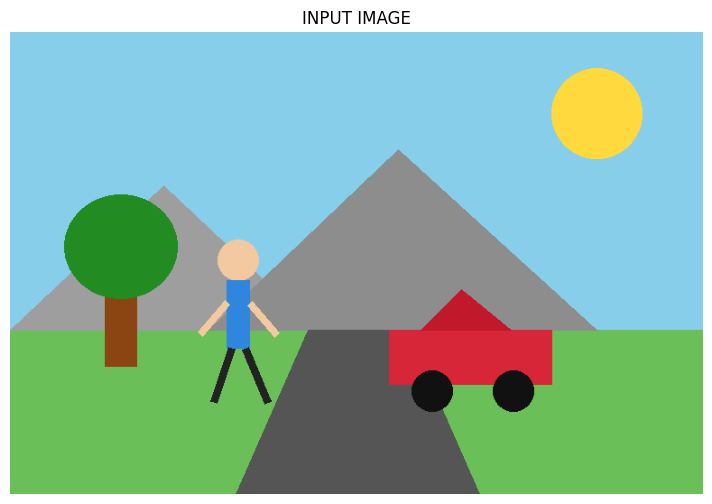

In [19]:
# DISPLAY INPUT IMAGE

plt.figure(figsize=(10,6))
plt.imshow(img)
plt.title("INPUT IMAGE")
plt.axis("off")
plt.show()

In [20]:
# CONVERT TO NUMPY

img_np = np.array(img)

In [21]:
# HELPER FUNCTIONS

def make_mask(condition):
    mask = condition(img_np)
    return (mask.astype(np.uint8) * 255)

def create_rgba(mask):
    rgba = np.zeros((H, W, 4), dtype=np.uint8)
    rgba[..., :3] = img_np
    rgba[..., 3] = mask
    return Image.fromarray(rgba)

In [22]:
# SEMANTIC MASKS

semantic_masks = {

    # PERSON
    "Person":
        make_mask(lambda x:
            (
                ((x[...,0] > 220) & (x[...,1] > 170) & (x[...,2] > 130)) |
                ((x[...,2] > 180) & (x[...,0] < 100))
            )
        ),

    # CAR
    "Car":
        make_mask(lambda x:
            (
                (x[...,0] > 150) &
                (x[...,1] < 100) &
                (x[...,2] < 120)
            )
        ),

    # TREE
    "Tree":
        make_mask(lambda x:
            (
                ((x[...,1] > 90) & (x[...,0] < 70)) |
                (
                    (x[...,0] > 100) &
                    (x[...,0] < 170) &
                    (x[...,1] > 40) &
                    (x[...,1] < 100)
                )
            )
        ),

    # ROAD
    "Road":
        make_mask(lambda x:
            (
                (x[...,0] > 60) & (x[...,0] < 100) &
                (x[...,1] > 60) & (x[...,1] < 100) &
                (x[...,2] > 60) & (x[...,2] < 100)
            )
        ),

    # SUN
    "Sun":
        make_mask(lambda x:
            (
                (x[...,0] > 220) &
                (x[...,1] > 190) &
                (x[...,2] < 120)
            )
        ),

    # MOUNTAINS
    "Mountains":
        make_mask(lambda x:
            (
                (x[...,0] > 130) & (x[...,0] < 180) &
                (x[...,1] > 130) & (x[...,1] < 180) &
                (x[...,2] > 130) & (x[...,2] < 180)
            )
        ),

    # GROUND
    "Ground":
        make_mask(lambda x:
            (
                (x[...,1] > 150) &
                (x[...,0] < 140) &
                (x[...,2] < 120)
            )
        ),

    # SKY
    "Sky":
        make_mask(lambda x:
            (
                (x[...,0] > 100) &
                (x[...,1] > 170) &
                (x[...,2] > 190)
            )
        )
}

print("Semantic Masks Created")

Semantic Masks Created


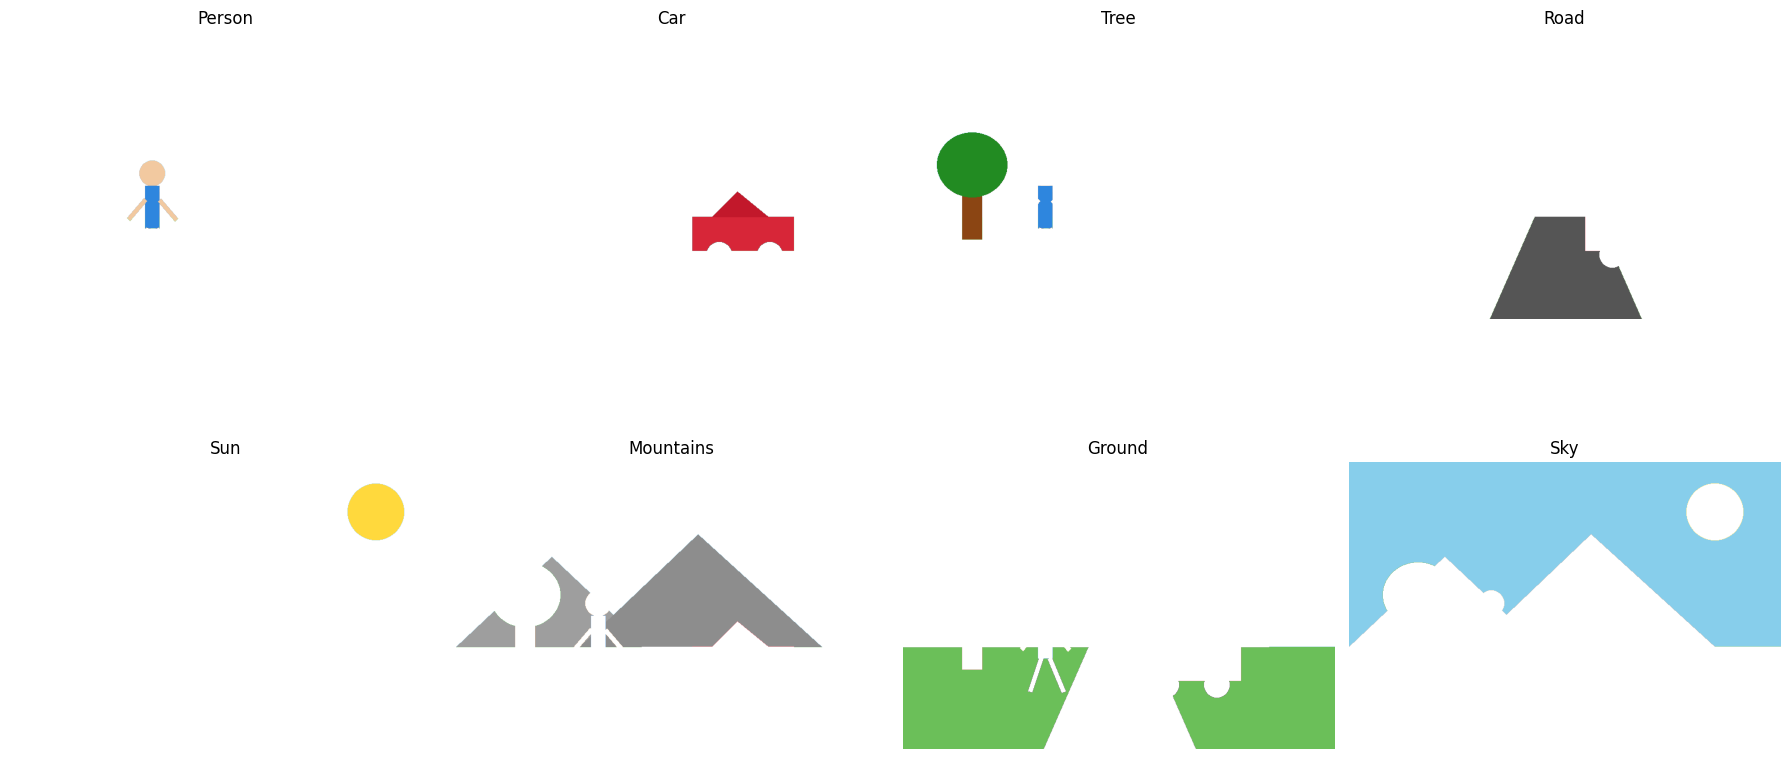

In [23]:

# DISPLAY SEMANTIC RGBA LAYERS

plt.figure(figsize=(18,10))

for i, (name, mask) in enumerate(semantic_masks.items()):

    layer = create_rgba(mask)

    plt.subplot(2,4,i+1)
    plt.imshow(layer)
    plt.title(name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [24]:
# DEPTH ORDER
# Near -> Far

depth_order = [
    "Person",
    "Car",
    "Tree",
    "Road",
    "Sun",
    "Mountains",
    "Ground",
    "Sky"
]

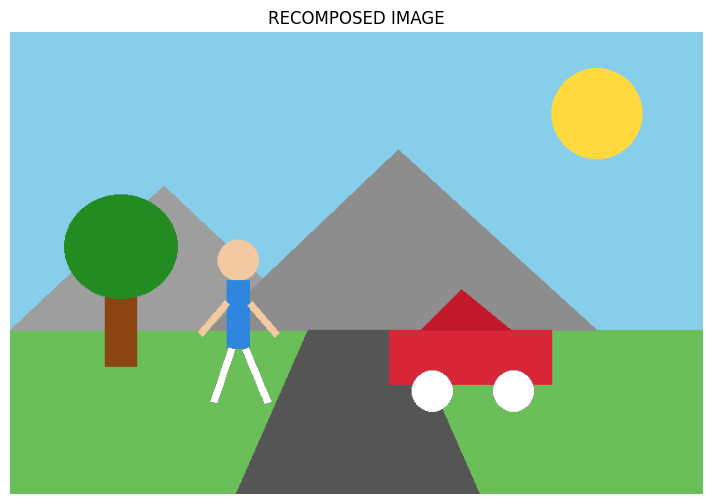

In [25]:
# RECOMPOSE IMAGE

canvas = Image.new("RGBA", (W, H), (0,0,0,0))

for name in reversed(depth_order):

    layer = create_rgba(semantic_masks[name])

    canvas = Image.alpha_composite(canvas, layer)

plt.figure(figsize=(10,6))
plt.imshow(canvas)
plt.title("RECOMPOSED IMAGE")
plt.axis("off")
plt.show()

In [26]:
# ALBEDO + SHADING FUNCTION

def get_albedo_shading(layer_img):

    arr = np.array(layer_img).astype(np.float32)

    rgb = arr[..., :3]
    alpha = arr[..., 3]

    gray = np.mean(rgb, axis=2, keepdims=True)

    shading = gray / 255.0
    shading = np.clip(shading, 0.15, 1.0)

    albedo = rgb / shading
    albedo = np.clip(albedo, 0, 255)

    albedo_img = np.dstack([albedo, alpha]).astype(np.uint8)

    shading_rgb = np.repeat(shading * 255, 3, axis=2)
    shading_img = np.dstack([shading_rgb, alpha]).astype(np.uint8)

    return albedo_img, shading_img

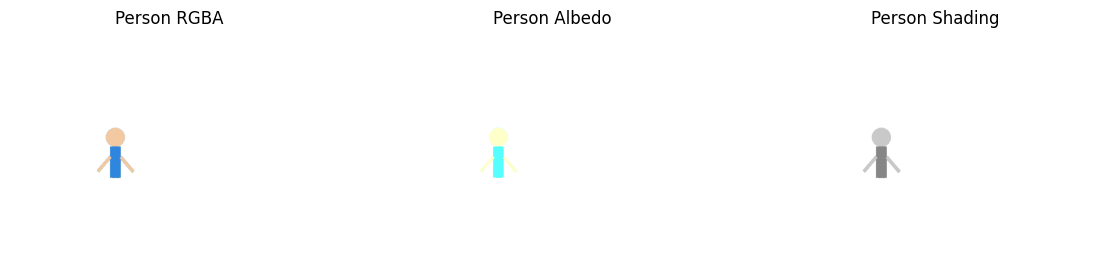

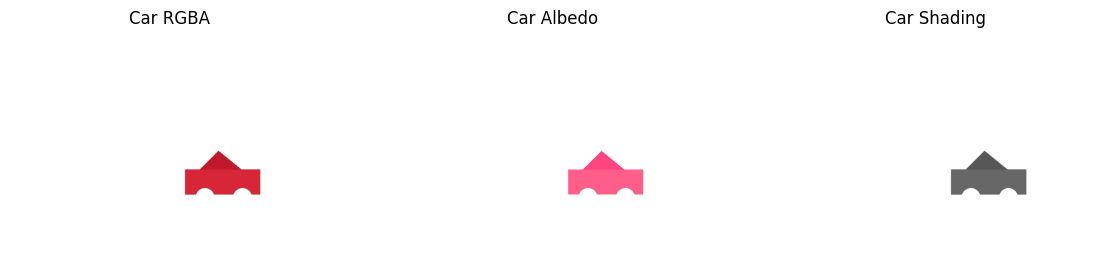

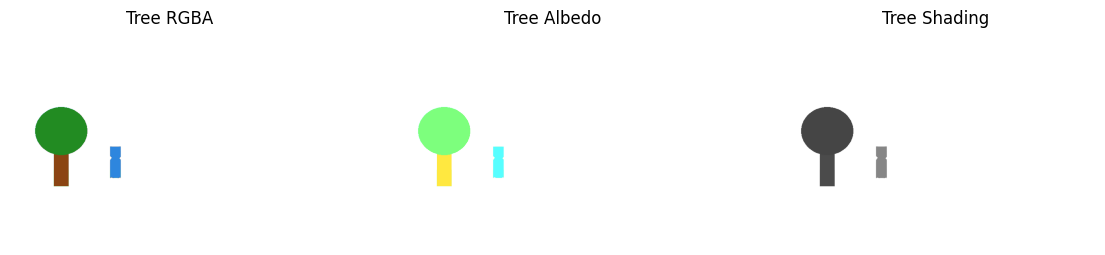

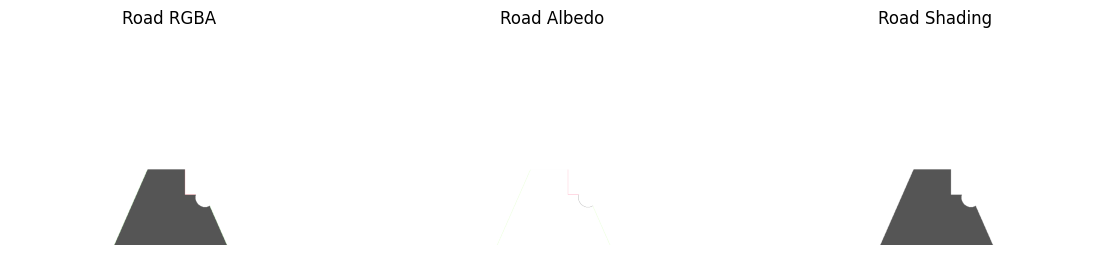

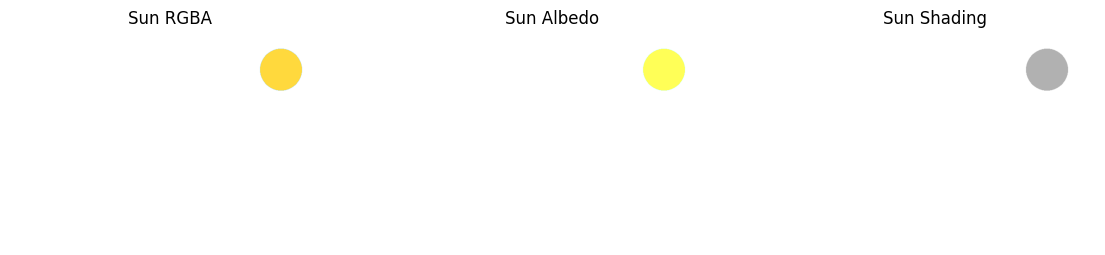

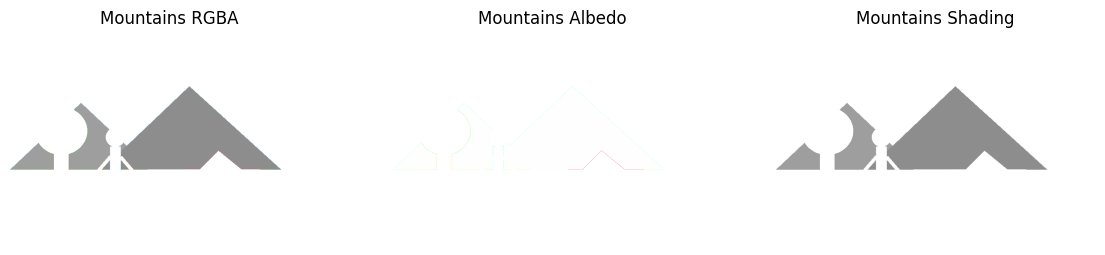

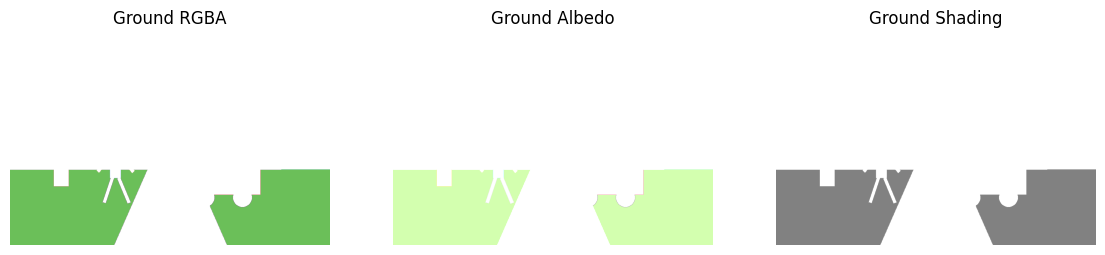

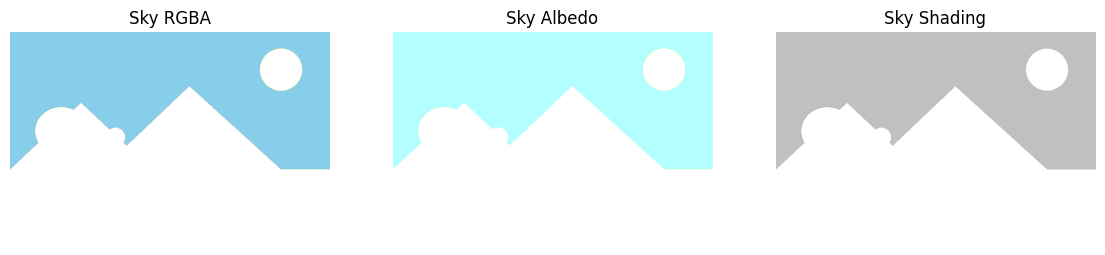

In [27]:
# DISPLAY ALBEDO + SHADING FOR ALL LAYERS

for name in depth_order:

    layer = create_rgba(semantic_masks[name])

    albedo_img, shading_img = get_albedo_shading(layer)

    plt.figure(figsize=(14,4))

    plt.subplot(1,3,1)
    plt.imshow(layer)
    plt.title(f"{name} RGBA")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(albedo_img)
    plt.title(f"{name} Albedo")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(shading_img)
    plt.title(f"{name} Shading")
    plt.axis("off")

    plt.show()

In [28]:
# SAVE OUTPUT FILES

import os
import zipfile

os.makedirs("Output/rgba_layers", exist_ok=True)
os.makedirs("Output/albedo_layers", exist_ok=True)
os.makedirs("Output/shading_layers", exist_ok=True)

# Save input image
img.save("Output/input_image.png")

# Save semantic RGBA layers + albedo + shading
for name in depth_order:
    layer = create_rgba(semantic_masks[name])
    albedo_img, shading_img = get_albedo_shading(layer)

    layer.save(f"Output/rgba_layers/{name}_rgba.png")
    Image.fromarray(albedo_img).save(f"Output/albedo_layers/{name}_albedo.png")
    Image.fromarray(shading_img).save(f"Output/shading_layers/{name}_shading.png")

# Save recomposed image
canvas.save("Output/recomposed_image.png")

# Create ZIP
zip_name = "layered_representations_Output.zip"

with zipfile.ZipFile(zip_name, "w") as zipf:
    for root, dirs, files in os.walk("Output"):
        for file in files:
            full_path = os.path.join(root, file)
            zipf.write(full_path)

print("Output files created successfully")
print("ZIP file ready:", zip_name)

# Download in Colab
from google.colab import files
files.download(zip_name)

Output files created successfully
ZIP file ready: layered_representations_Output.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>